# 데이터마이닝 6주차 실습

### 주성분 분석 PCA는 주 목적이 Predict(예측)이 아님 Dimension Reduction(차원 축소)이 주 목적

## PCA IRIS 데이터

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
# 1. Iris 데이터셋 로드
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names
print(target_names)

['setosa' 'versicolor' 'virginica']


In [3]:

# 2. 데이터 표준화 (Standardization)
# PCA는 특성 간의 스케일에 민감하므로 평균 0, 분산 1로 표준화합니다.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



In [20]:
# 3. PCA 적용
pca = PCA(n_components=2) # 4에서 2로 차원축소
X_pca = pca.fit_transform(X_scaled)

# 결과 데이터프레임 생성
# df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2', 'PC3', 'PC4']) # Principal Component
df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2']) # Principal Component
df_pca['target'] = y
df_pca['Species'] = df_pca['target'].map({i:name for i, name in enumerate(target_names)})

df_pca.head()


,PC1,PC2,target,Species
0,-2.264703,0.480027,0,setosa
1,-2.080961,-0.674134,0,setosa
2,-2.364229,-0.341908,0,setosa
3,-2.299384,-0.597395,0,setosa
4,-2.389842,0.646835,0,setosa


In [ ]:
# 4. 주성분별 설명된 분산 비율(Explained Variance Ratio) 출력
print("각 주성분별 설명력 (분산 비율):", pca.explained_variance_ratio_)
print(f"모든 주성분의 총 설명력: {sum(pca.explained_variance_ratio_):.4f}")

각 주성분별 설명력 (분산 비율): [0.72962445 0.22850762 0.03668922 0.00517871]
모든 주성분의 총 설명력: 1.0000


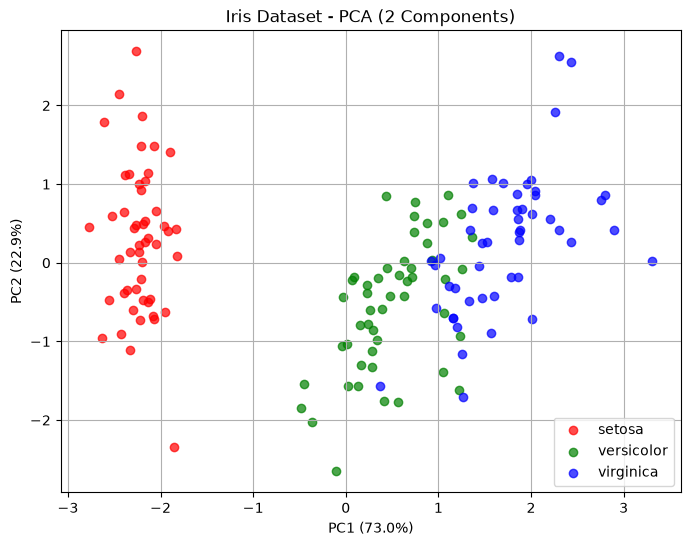

In [15]:
# 5. 시각화

# PCA 2개일때
plt.figure(figsize=(8, 6))
colors = ['red', 'green', 'blue']

for target, color, name in zip(range(3), colors, target_names):
    subset = df_pca[df_pca['target'] == target]
    plt.scatter(subset['PC1'], subset['PC2'], c=color, label=name, alpha=0.7)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('Iris Dataset - PCA (2 Components)')
plt.legend()
plt.grid(True)


# PCA 4개일때
# fig = plt.figure(figsize=(9, 7))
# ax = fig.add_subplot(111, projection='3d')

# # PC1, PC2, PC3를 공간 축으로, PC4를 색상(c)으로 매핑
# scatter = ax.scatter(
#     df_pca['PC1'], 
#     df_pca['PC2'], 
#     df_pca['PC3'], 
#     c=df_pca['PC4'],      # PC4를 색상으로 표현
#     cmap='viridis', 
#     s=50
# )

# # 축 라벨 지정
# ax.set_xlabel('PC1')
# ax.set_ylabel('PC2')
# ax.set_zlabel('PC3')

# # PC4 색상바(Colorbar) 라벨 지정
# cbar = fig.colorbar(scatter, ax=ax, pad=0.1)
# cbar.set_label('PC4 Value')

# plt.title('3D Scatter Plot with PC4 mapped to Color')


plt.show()

In [23]:
# Eigen vectors 참고(Python은 Vectors 보여주는게 행으로 보여줌)
pca.components_

array([[ 0.52106591, -0.26934744,  0.5804131 ,  0.56485654],
       [ 0.37741762,  0.92329566,  0.02449161,  0.06694199]])

In [24]:
# Eigen values
pca.explained_variance_

array([2.93808505, 0.9201649 ])

## PCA 모나리자 이미지
### 이미지 주성분 분석(PCA)은 2차원 픽셀 행렬을 저차원 주성분의 조합으로 근구현하는 데이터 압축(Image Compression) 기법

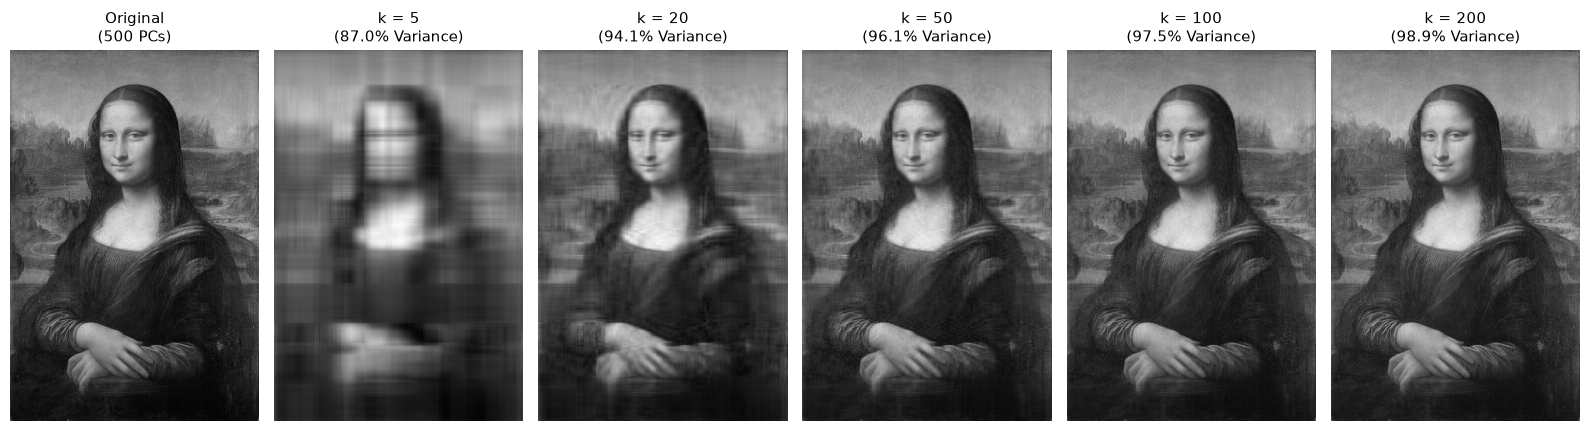

In [26]:
import os
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.decomposition import PCA

# 1. 모나리자 이미지 불러오기 (파일이 없는 경우 자동 다운로드)
img_path = 'mona_lisa.jpg'
if not os.path.exists(img_path):
    url = "https://thumb.wikimedia.org/wikipedia/commons/thumb/e/ec/Mona_Lisa%2C_by_Leonardo_da_Vinci%2C_from_C2RMF_retouched.jpg/500px-Mona_Lisa%2C_by_Leonardo_da_Vinci%2C_from_C2RMF_retouched.jpg?utm_source=ko.wikipedia.org&utm_campaign=index&utm_content=thumbnail"
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req) as response, open(img_path, 'wb') as out_file:
        out_file.write(response.read())

# 2. 이미지를 흑백(Grayscale)으로 변환 후 NumPy 배열화
img = Image.open(img_path).convert('L')
img_mat = np.array(img) # (높이, 너비) 형태의 2차원 행렬

# 3. 비교할 주성분 개수(k) 설정
n_components_list = [5, 20, 50, 100, 200]

plt.figure(figsize=(16, 6))

# 원본 이미지 출력
plt.subplot(1, len(n_components_list) + 1, 1)
plt.imshow(img_mat, cmap='gray')
plt.title(f'Original\n({img_mat.shape[1]} PCs)', fontsize=11)
plt.axis('off')

# 주성분 개수별 복원 실행 및 비교
for i, k in enumerate(n_components_list):
    # PCA 모델 학습 및 차원 축소 -> 역변환으로 복원
    pca = PCA(n_components=k)
    img_transformed = pca.fit_transform(img_mat)
    img_reconstructed = pca.inverse_transform(img_transformed)
    
    # 누적 설명 분산 비율 (정보 보존율)
    var_ratio = np.sum(pca.explained_variance_ratio_) * 100
    
    plt.subplot(1, len(n_components_list) + 1, i + 2)
    plt.imshow(img_reconstructed, cmap='gray')
    plt.title(f'k = {k}\n({var_ratio:.1f}% Variance)', fontsize=11)
    plt.axis('off')

plt.tight_layout()
plt.show()

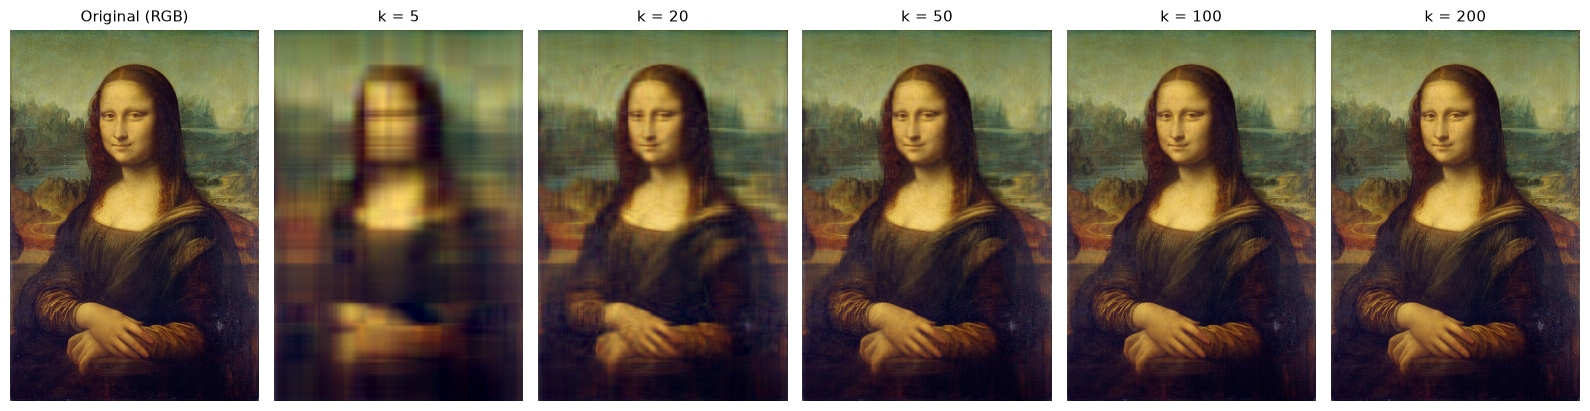

In [27]:
# 1. RGB 컬러 이미지 로드
img_rgb = Image.open(img_path).convert('RGB')
img_rgb_mat = np.array(img_rgb)

n_components_list = [5, 20, 50, 100, 200]

plt.figure(figsize=(16, 6))

plt.subplot(1, len(n_components_list) + 1, 1)
plt.imshow(img_rgb_mat)
plt.title('Original (RGB)', fontsize=11)
plt.axis('off')

for i, k in enumerate(n_components_list):
    reconstructed_channels = []
    
    # R, G, B 채널별 독립적 PCA 수행
    for channel in range(3):
        pca = PCA(n_components=k)
        transformed = pca.fit_transform(img_rgb_mat[:, :, channel])
        reconstructed = pca.inverse_transform(transformed)
        reconstructed_channels.append(reconstructed)
    
    # 3개 채널 결합 및 픽셀 값 범위([0, 255]) 정규화
    img_reconstructed = np.stack(reconstructed_channels, axis=2)
    img_reconstructed = np.clip(img_reconstructed, 0, 255).astype(np.uint8)
    
    plt.subplot(1, len(n_components_list) + 1, i + 2)
    plt.imshow(img_reconstructed)
    plt.title(f'k = {k}', fontsize=11)
    plt.axis('off')

plt.tight_layout()
plt.show()